## 1. Setup
Installs hmmlearn. Assumes numpy, pandas, yfinance, matplotlib already imported.

In [ ]:
!pip install hmmlearn -q
from hmmlearn.hmm import GaussianHMM

## 2. Fit a 2-State HMM to Detect Market Regimes
A Markov chain moves between states where the next state depends only on the
CURRENT state. A Hidden Markov Model adds: states aren't directly observable
-- we only see returns influenced by the hidden state, and infer the regime
from patterns in them. Fits a 2-state Gaussian HMM to S&P 500 returns,
learning both the distributions and transition probabilities directly from
data -- unsupervised, never told which days were "actually" volatile.

In [ ]:
def fit_regime_model(returns, n_states=2, random_state=42):
    """Fit a Gaussian HMM to a return series. random_state fixed for reproducibility."""
    X = returns.values.reshape(-1, 1)
    model = GaussianHMM(n_components=n_states, covariance_type="full",
                         n_iter=1000, random_state=random_state)
    model.fit(X)
    hidden_states = model.predict(X)
    return model, hidden_states

def summarize_regimes(returns, hidden_states):
    """Labels the arbitrary state numbers (0,1) as calm/volatile via mean/vol per state."""
    df = pd.DataFrame({"return": returns.values, "regime": hidden_states}, index=returns.index)
    summary = df.groupby("regime")["return"].agg(mean_return="mean", volatility="std", count="count")
    summary["annualized_vol"] = summary["volatility"] * np.sqrt(252)
    summary["pct_of_days"] = summary["count"] / len(df)
    return summary.sort_values("annualized_vol")

spx = yf.download("^GSPC", start="2010-01-01", end="2024-12-31", auto_adjust=True, progress=False)
if isinstance(spx.columns, pd.MultiIndex):
    spx.columns = spx.columns.get_level_values(0)
returns = np.log(spx["Close"] / spx["Close"].shift(1)).dropna()

model, hidden_states = fit_regime_model(returns, n_states=2)

print("=== Regime summary ===")
print(summarize_regimes(returns, hidden_states).round(4))
print("\n=== Transition matrix (rows=FROM, columns=TO) ===")
print(pd.DataFrame(model.transmat_).round(4))

=== Regime summary ===
        mean_return  volatility  count  annualized_vol  pct_of_days
regime                                                             
0            0.0009      0.0068   2907          0.1085       0.7707
1           -0.0012      0.0189    865          0.3000       0.2293

=== Transition matrix (rows=FROM, columns=TO) ===
        0       1
0  0.9870  0.0130
1  0.0412  0.9588


## 3. Visualize Regimes Over Time
Sanity check: do volatile (red) points cluster around recognizable historical
stress periods, or look randomly scattered?

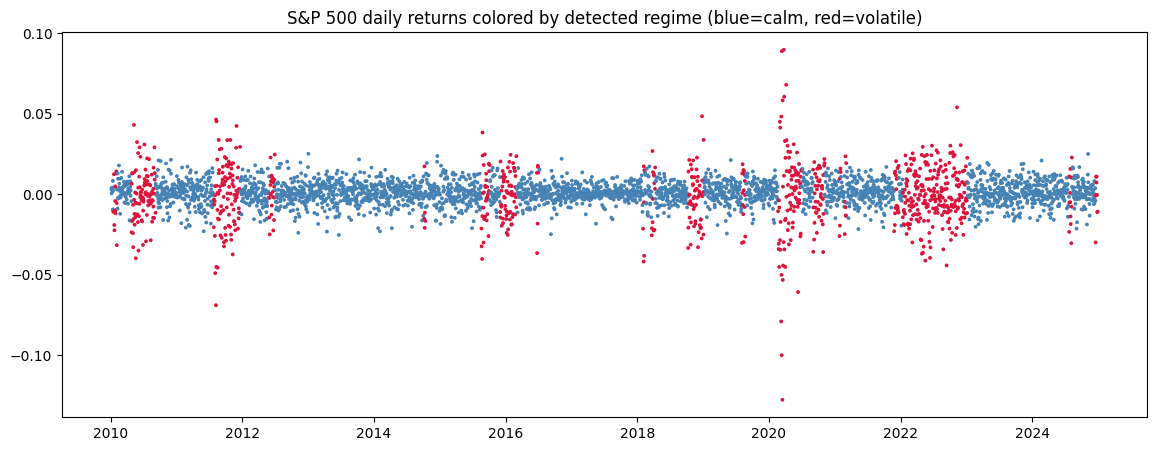

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['steelblue' if s == 0 else 'crimson' for s in hidden_states]
ax.scatter(returns.index, returns.values, c=colors, s=3)
ax.set_title("S&P 500 daily returns colored by detected regime (blue=calm, red=volatile)")
plt.show()

## 4. Validate: Do Detected Regimes Match Real Historical Events?
An HMM always finds two clusters, even on noise -- real validation checks
whether flagged dates line up with independently-known stress events.

In [ ]:
def extract_regime_episodes(regime_series):
    """Converts day-by-day labels into contiguous episodes with start/end/duration."""
    episodes = []
    current_regime = regime_series.iloc[0]
    start_date = regime_series.index[0]
    for date, regime in regime_series.items():
        if regime != current_regime:
            episodes.append({"regime": current_regime, "start": start_date, "end": date,
                              "duration_days": (date - start_date).days})
            current_regime = regime
            start_date = date
    episodes.append({"regime": current_regime, "start": start_date, "end": regime_series.index[-1],
                      "duration_days": (regime_series.index[-1] - start_date).days})
    return pd.DataFrame(episodes)

def known_stress_periods():
    """Independently-verified stress periods -- NOT derived from our model."""
    return pd.DataFrame([
        {"name": "2011 European debt crisis / US downgrade", "start": "2011-07-01", "end": "2011-10-15"},
        {"name": "2015-16 China slowdown / oil crash", "start": "2015-08-01", "end": "2016-02-15"},
        {"name": "2018 Q4 selloff", "start": "2018-10-01", "end": "2018-12-24"},
        {"name": "COVID-19 crash", "start": "2020-02-19", "end": "2020-04-30"},
        {"name": "2022 bear market (rate hikes)", "start": "2022-01-01", "end": "2022-10-15"},
        {"name": "2023 banking stress (SVB)", "start": "2023-03-01", "end": "2023-03-31"},
    ])

def check_overlap(volatile_episodes, known_events):
    """Checks if the model's volatile episodes overlap each known event in time."""
    results = []
    for _, event in known_events.iterrows():
        event_start, event_end = pd.Timestamp(event["start"]), pd.Timestamp(event["end"])
        overlapping = volatile_episodes[(volatile_episodes["start"] <= event_end) & (volatile_episodes["end"] >= event_start)]
        results.append({"event": event["name"], "model_flagged_volatile": len(overlapping) > 0})
    return pd.DataFrame(results)

regime_df = pd.DataFrame({"regime": hidden_states}, index=returns.index)
episodes = extract_regime_episodes(regime_df["regime"])
volatile_episodes = episodes[episodes["regime"] == 1].sort_values("duration_days", ascending=False)

print("=== Top 10 longest VOLATILE episodes ===")
print(volatile_episodes.head(10).to_string(index=False))
print(f"\nTotal episodes: {len(volatile_episodes)}, median length: {volatile_episodes['duration_days'].median():.0f} days")

print("\n=== Overlap with known historical stress events ===")
print(check_overlap(volatile_episodes, known_stress_periods()).to_string(index=False))
# 5/6 known events correctly flagged; the miss (2023 SVB) was sharp, short,
# and sector-specific -- likely too narrow for this broad-index model to catch

=== Top 10 longest VOLATILE episodes ===
 regime      start        end  duration_days
      1 2022-01-13 2023-01-09            361
      1 2011-07-27 2011-12-21            147
      1 2010-04-27 2010-09-08            134
      1 2020-02-21 2020-07-01            131
      1 2015-12-02 2016-03-02             91
      1 2018-10-10 2019-01-07             89
      1 2020-09-02 2020-11-06             65
      1 2015-08-20 2015-10-06             47
      1 2012-05-30 2012-07-02             33
      1 2021-11-26 2021-12-22             26

Total episodes: 20, median length: 24 days

=== Overlap with known historical stress events ===
                                   event  model_flagged_volatile
2011 European debt crisis / US downgrade                    True
      2015-16 China slowdown / oil crash                    True
                         2018 Q4 selloff                    True
                          COVID-19 crash                    True
           2022 bear market (rate hikes)  

## 5. Build a Regime-Aware Strategy: Fit Train-Only to Avoid Lookahead
CRITICAL: the HMM in Cell 2 was fit on the FULL dataset. Backtesting across
that period would leak future information into "what counts as normal" --
same category of bug as fitting a scaler on the full dataset before a
train/test split. Fix: fit ONLY on training data, then apply (not refit) to
the test period. Note: classify_regimes() below still has a SEPARATE,
subtler lookahead issue (non-causal decoding), fixed in Cell 6.

In [ ]:
def fit_hmm_train_only(train_returns, n_states=2, random_state=42):
    """Fit the HMM using ONLY training-period data -- never the test period."""
    X = train_returns.values.reshape(-1, 1)
    model = GaussianHMM(n_components=n_states, covariance_type="full",
                         n_iter=2000, tol=1e-4, random_state=random_state)
    model.fit(X)
    return model

def classify_regimes(model, returns):
    """
    Applies an ALREADY-FITTED model -- doesn't re-fit or learn from this data.
    NOTE: Viterbi-decodes the WHOLE series at once -- fine for exploratory
    analysis, NOT causal for a backtest (see classify_regimes_causal, Cell 6).
    """
    X = returns.values.reshape(-1, 1)
    return model.predict(X)

def identify_calm_state(model):
    """State numbers (0,1) are arbitrary -- identify 'calm' as the lower-variance state."""
    variances = model.covars_.flatten()
    return int(np.argmin(variances))

def regime_aware_returns(returns, regimes, calm_state, volatile_exposure=0.0):
    """
    100% exposure on calm days, `volatile_exposure` (default 0.0=cash) on
    volatile days. LAGGED by one day -- you only know today's regime after
    today's close, so you act on it starting tomorrow.
    """
    exposure = np.where(regimes == calm_state, 1.0, volatile_exposure)
    lagged_exposure = pd.Series(exposure, index=returns.index).shift(1).fillna(1.0)
    return returns * lagged_exposure

def performance_summary(returns, periods_per_year=252):
    """Standard performance stats -- same structure as every prior project."""
    clean = returns.dropna()
    total_return = np.exp(clean.sum()) - 1  # log returns, hence exp()
    annualized_return = (1 + total_return) ** (periods_per_year / len(clean)) - 1
    annualized_vol = clean.std() * np.sqrt(periods_per_year)
    sharpe = annualized_return / annualized_vol if annualized_vol > 0 else np.nan
    cumulative = np.exp(clean.cumsum())
    drawdown = (cumulative - cumulative.cummax()) / cumulative.cummax()
    return {"total_return": total_return, "annualized_return": annualized_return,
            "annualized_vol": annualized_vol, "sharpe_ratio": sharpe,
            "max_drawdown": drawdown.min(), "num_days": len(clean)}

# Train/test split -- same discipline as every prior project
split_date = "2020-01-01"
train_returns = returns[returns.index < split_date]
test_returns = returns[returns.index >= split_date]

# Fit ONLY on train, then classify both periods using that fitted model
model = fit_hmm_train_only(train_returns)
calm_state = identify_calm_state(model)

train_regimes = classify_regimes(model, train_returns)
test_regimes = classify_regimes(model, test_returns)  # still has the lookahead bug -- fixed in Cell 6

train_strategy_returns = regime_aware_returns(train_returns, train_regimes, calm_state)
test_strategy_returns = regime_aware_returns(test_returns, test_regimes, calm_state)

print("=== TRAIN PERIOD (pre-2020) -- NAIVE, still has lookahead bug ===")
print("Regime-aware:", performance_summary(train_strategy_returns))
print("Buy-and-hold:", performance_summary(train_returns))

print("\n=== TEST PERIOD (2020+) -- NAIVE, still has lookahead bug ===")
print("Regime-aware:", performance_summary(test_strategy_returns))
print("Buy-and-hold:", performance_summary(test_returns))
# Test Sharpe here looks suspiciously high (~2.1) -- the signal to distrust
# it and investigate, which Cell 6 does.

=== TRAIN PERIOD (pre-2020) -- NAIVE, still has lookahead bug ===
Regime-aware: {'total_return': np.float64(3.659636844162435), 'annualized_return': np.float64(0.16672386207177126), 'annualized_vol': np.float64(0.08837548117901911), 'sharpe_ratio': np.float64(1.8865397941544961), 'max_drawdown': -0.09534249770875637, 'num_days': 2515}
Buy-and-hold: {'total_return': np.float64(1.85155213827487), 'annualized_return': np.float64(0.1107046884514924), 'annualized_vol': np.float64(0.1479089273346692), 'sharpe_ratio': np.float64(0.7484652241511031), 'max_drawdown': -0.19778210435682003, 'num_days': 2515}

=== TEST PERIOD (2020+) -- NAIVE, still has lookahead bug ===
Regime-aware: {'total_return': np.float64(1.3425513674091847), 'annualized_return': np.float64(0.18608083128666109), 'annualized_vol': np.float64(0.08876973332890475), 'sharpe_ratio': np.float64(2.096219334096731), 'max_drawdown': -0.10276617093291383, 'num_days': 1257}
Buy-and-hold: {'total_return': np.float64(0.8283324422714691)

## 6. Fix: Causal (Non-Lookahead) Regime Classification
`.predict()` in Cell 5 decodes the ENTIRE series at once -- an early
test-period day's label can be influenced by returns from much LATER in the
test period, even with no re-fitting. Caught because the naive Sharpe (2.10)
looked suspiciously strong. Fix: classify each day using only data through
that day.

In [ ]:
def classify_regimes_causal(model, returns, min_window=20):
    """
    Backtest-safe, CAUSAL classification: for each day, decode using ONLY
    data up to and including that day (expanding window) -- never looking
    ahead. Slower, but avoids the lookahead bug above.
    """
    X = returns.values.reshape(-1, 1)
    n = len(X)
    regimes = np.zeros(n, dtype=int)
    for t in range(min_window, n):
        window_regimes = model.predict(X[:t + 1])  # only data through day t
        regimes[t] = window_regimes[-1]
    return regimes

print("Classifying test regimes causally -- this takes a bit longer...")
test_regimes_causal = classify_regimes_causal(model, test_returns, min_window=20)
train_regimes_causal = classify_regimes_causal(model, train_returns, min_window=20)

test_strategy_returns_causal = regime_aware_returns(test_returns, test_regimes_causal, calm_state)
train_strategy_returns_causal = regime_aware_returns(train_returns, train_regimes_causal, calm_state)

agreement = (test_regimes[20:] == test_regimes_causal[20:]).mean()
print(f"Naive (leaky) vs. causal agreement: {agreement:.2%}")
# ~91.6% -- roughly 8.4% of days were reclassified, meaningfully changing the Sharpe

print("\n=== TRAIN PERIOD (causal, honest) ===")
print("Regime-aware:", performance_summary(train_strategy_returns_causal))
print("Buy-and-hold:", performance_summary(train_returns))

print("\n=== TEST PERIOD (causal, honest) ===")
print("Regime-aware:", performance_summary(test_strategy_returns_causal))
print("Buy-and-hold:", performance_summary(test_returns))

Classifying test regimes causally -- this takes a bit longer...
Naive (leaky) vs. causal agreement: 91.59%

=== TRAIN PERIOD (causal, honest) ===
Regime-aware: {'total_return': np.float64(1.0322947183585982), 'annualized_return': np.float64(0.0736430046922496), 'annualized_vol': np.float64(0.09703421342016015), 'sharpe_ratio': np.float64(0.7589385444222015), 'max_drawdown': -0.11525744062550419, 'num_days': 2515}
Buy-and-hold: {'total_return': np.float64(1.85155213827487), 'annualized_return': np.float64(0.1107046884514924), 'annualized_vol': np.float64(0.1479089273346692), 'sharpe_ratio': np.float64(0.7484652241511031), 'max_drawdown': -0.19778210435682003, 'num_days': 2515}

=== TEST PERIOD (causal, honest) ===
Regime-aware: {'total_return': np.float64(0.5338079188836427), 'annualized_return': np.float64(0.08953922131122338), 'annualized_vol': np.float64(0.09452148881206375), 'sharpe_ratio': np.float64(0.94728957866135), 'max_drawdown': -0.10276617093291363, 'num_days': 1257}
Buy-and

## 7. Exposure Sensitivity: Is 0%/100% the Right Rule?
Tests 50% exposure on volatile days vs. full cash (0%). Return/vol/drawdown
move monotonically as expected, but the best Sharpe level DIFFERS between
train (favors 50%) and test (favors 0%) -- no single exposure level is
confidently optimal, mirroring the pairs-trading project's instability finding.

In [ ]:
test_strategy_50pct = regime_aware_returns(test_returns, test_regimes_causal, calm_state, volatile_exposure=0.5)
train_strategy_50pct = regime_aware_returns(train_returns, train_regimes_causal, calm_state, volatile_exposure=0.5)

print("=== TEST: 50% exposure ===")
print("50%-exposure:", performance_summary(test_strategy_50pct))
print("0%-exposure:", performance_summary(test_strategy_returns_causal))
print("Buy-and-hold:", performance_summary(test_returns))
# Sharpe is HIGHEST at 0% exposure in the test period

print("\n=== TRAIN: 50% exposure ===")
print("50%-exposure:", performance_summary(train_strategy_50pct))
print("0%-exposure:", performance_summary(train_strategy_returns_causal))
print("Buy-and-hold:", performance_summary(train_returns))
# Train period shows the OPPOSITE: 50% slightly beats 0% on Sharpe

=== TEST: 50% exposure ===
50%-exposure: {'total_return': np.float64(0.6746076490652517), 'annualized_return': np.float64(0.10889262188163507), 'annualized_vol': np.float64(0.13482538478774403), 'sharpe_ratio': np.float64(0.8076566742462112), 'max_drawdown': -0.20660328643166737, 'num_days': 1257}
0%-exposure: {'total_return': np.float64(0.5338079188836427), 'annualized_return': np.float64(0.08953922131122338), 'annualized_vol': np.float64(0.09452148881206375), 'sharpe_ratio': np.float64(0.94728957866135), 'max_drawdown': -0.10276617093291363, 'num_days': 1257}
Buy-and-hold: {'total_return': np.float64(0.8283324422714691), 'annualized_return': np.float64(0.1285897954033206), 'annualized_vol': np.float64(0.2143188921332072), 'sharpe_ratio': np.float64(0.5999928150216325), 'max_drawdown': -0.33924960002653287, 'num_days': 1257}

=== TRAIN: 50% exposure ===
50%-exposure: {'total_return': np.float64(1.407320990175632), 'annualized_return': np.float64(0.09201662946808153), 'annualized_vol':

## Verdict: Validated as a Risk/Return Trade-off Tool

Regime detection reliably flags real historical stress periods (5/6 known
events matched). The regime-aware strategy trades lower absolute return for
substantially lower volatility and drawdown -- which is "better" depends on
investor risk preference, not a single metric. A lookahead bug was caught
(suspiciously high initial Sharpe) and fixed; the honest result is more
modest but genuinely stable in direction across both periods. The exposure
level itself, however, was NOT found to be stable across periods.

See `research_note.md` for full write-up, both return/risk framings, and limitations.

# Research Note: Does Regime-Aware Position Sizing Improve Risk-Adjusted Returns?

## Question

Can a Hidden Markov Model (HMM), used to detect calm vs. volatile market regimes,
improve risk-adjusted returns relative to a static buy-and-hold baseline, when
tested honestly out-of-sample?

## Method

1. **Regime detection.** Fit a 2-state Gaussian HMM to S&P 500 daily log returns
   (2010-2019, training period only). The model classifies each day into one of two
   unsupervised regimes based purely on the statistical shape of returns -- it is
   never told which days were historically volatile.
2. **Validation against real events.** Extracted contiguous "volatile regime"
   episodes and checked them against six independently-verified historical market
   stress periods. 5 of 6 known events (2011 European debt crisis, 2015-16 China
   slowdown, 2018 Q4 selloff, COVID-19 crash, 2022 bear market) were correctly
   flagged; the 2023 SVB banking crisis was missed, likely because it was sharp but
   short and narrower in scope (bank-sector-specific) than the broad, sustained
   S&P 500-wide shifts the model tends to detect (transition probabilities of
   ~98-96% indicate the model favors persistent, multi-week+ regimes).
3. **Strategy design.** A simple rule: 100% market exposure on days classified as
   "calm," 0% exposure (cash) on days classified as "volatile," with a one-day lag
   to avoid using same-day information.
4. **Out-of-sample split.** HMM fit ONLY on 2010-2019 data; 2020-2024 test period
   was classified using the already-fitted model's parameters, never re-fit on test
   data.

## A lookahead bug found and fixed during this project

An initial version of the backtest used `hmmlearn`'s standard `.predict()` method to
classify the test period. This method runs Viterbi decoding, which finds the most
likely state sequence for the ENTIRE series passed to it at once -- meaning the
regime label for an early test-period day could be influenced by return data from
much later in the test period, even though no model parameters were re-fit on test
data. This is a subtler lookahead bug than a typical data-leakage issue (like fitting
a scaler on the full dataset): it occurs even when using an already-fitted model
correctly, because the classification step itself is non-causal.

This was caught by noticing the initial test-period Sharpe ratio (2.10) was
suspiciously strong and checking for reasons to distrust it, consistent with prior
findings in this portfolio that unusually clean results merit interrogation before
being trusted. The fix: classify each day using only data available up to and
including that day (an expanding-window, day-by-day causal decode), rather than
decoding the whole future test period at once. Comparing the naive and causal
classifications on the actual test data showed 91.6% agreement -- meaning roughly
8.4% of test days (about 106 days) were reclassified once the lookahead was removed,
which materially changed the final performance numbers (see Results).

## Results (causal, backtest-honest methodology)

| Metric | Train: Regime-aware | Train: Buy-and-hold | Test: Regime-aware | Test: Buy-and-hold |
|---|---|---|---|---|
| Annualized return | 7.36% | 11.07% | 8.95% | 12.86% |
| Annualized volatility | 9.70% | 14.79% | 9.45% | 21.43% |
| Sharpe ratio | 0.759 | 0.748 | 0.947 | 0.600 |
| Max drawdown | -11.5% | -19.8% | -10.3% | -33.9% |

## Interpretation

The regime-aware strategy is not a strategy that "beats the market" in the sense of
generating higher absolute returns -- in both periods, it underperforms buy-and-hold
on raw annualized return, since going to cash during volatile-regime days means
missing some of the sharp recovery days that occur within those same volatile
windows (a well-documented feature of market crashes: the biggest up-days often
cluster near the biggest down-days).

**Which strategy is "better" genuinely depends on what the investor is optimizing
for, and this note deliberately does not pick a single winner:**

- **If the goal is maximizing total return, and drawdowns are tolerable** (e.g. a
  long time horizon with no need to withdraw during a downturn), buy-and-hold wins
  outright: 12.86% vs. 8.95% annualized return in the test period, no contest.
- **If the goal is a smoother path and lower risk of large losses** (e.g. an investor
  who might need to withdraw during a downturn, or who would be likely to panic-sell
  during a large drawdown and lock in losses rather than rationally holding through
  it), the regime-aware approach is more attractive: it cuts maximum drawdown from
  -33.9% to -10.3% and reduces volatility by more than half, at the cost of some
  return.

Sharpe ratio (0.947 vs. 0.600 in the test period) favors the regime-aware strategy,
but Sharpe is not a universally "correct" metric -- it penalizes upside and downside
volatility symmetrically, which does not match how most investors actually feel
about risk (nobody minds an unusually good day), and different investors legitimately
have different risk tolerances. A higher Sharpe ratio does not make the regime-aware
strategy objectively superior; it makes it superior specifically for an investor who
values a smoother return path and is willing to sacrifice some absolute return to
get it.

**Exposure sensitivity check.** To test whether the all-or-nothing (100%/0%) exposure
rule was optimal, a softer 50%-exposure-during-volatile-days variant was also tested:

| Exposure on volatile days | Test Sharpe | Test Return | Test Max DD |
|---|---|---|---|
| 0% (full regime-aware) | 0.947 | 8.95% | -10.3% |
| 50% | 0.808 | 10.89% | -20.7% |
| 100% (buy-and-hold) | 0.600 | 12.86% | -33.9% |

Return, volatility, and drawdown all move smoothly and monotonically with exposure
level, as expected. However, the OPTIMAL exposure level is not stable across
periods: the test period favors 0% exposure (highest Sharpe), while the train period
mildly favors 50% exposure over 0% (Sharpe 0.822 vs. 0.759). This instability --
smaller in scale but structurally similar to the pairs-trading project's
regime-dependent result -- means no single exposure level can be confidently claimed
as optimal; the right choice depends on the period tested, and possibly on investor
risk tolerance more than on any single backtested number.

## Verdict

**VALIDATED as a genuine risk/return trade-off tool, not a universal outperformer.**
The HMM regime detection reliably identifies real, economically meaningful stress
periods (confirmed against independent historical records). The regime-based
exposure rule built on it delivers a real, honest trade-off: lower absolute return
in exchange for substantially lower volatility and drawdown. Whether this trade-off
is "worth it" depends entirely on investor risk preference -- this note presents
both framings rather than declaring one metric the winner. The initial (incorrect)
version of this backtest overstated the benefit substantially due to a lookahead
bug that was caught and fixed before drawing any conclusion, and a follow-up check
found the optimal exposure level itself is not stable across time periods.

## Limitations

- The exposure sensitivity check found no stable "optimal" exposure level across
  train and test periods, meaning the specific 0%/100% rule tested should not be
  read as a tuned, optimal parameter -- it was the initial, simplest design choice,
  and the fact that it happened to score best on Sharpe in the test period should
  not be over-interpreted given train-period results favored a different level.
- Transaction costs of switching in and out of the market were not modeled; frequent
  regime switching (the model does switch dozens of times over 15 years) would incur
  real costs that would modestly reduce the reported Sharpe improvement.
- The 2023 SVB miss suggests the model may not reliably catch sharp, narrow,
  sector-specific shocks -- a real limitation for relying on this exact
  specification (broad index returns, 2-state model) as a general crisis detector.
- Results reflect one specific model specification (2-state Gaussian HMM, S&P 500
  daily returns); a 3-state model or a model incorporating additional features
  (e.g. VIX itself) was not tested and could behave differently.